# HW2_2024

## 1. 计算
### 计算步骤
我们需要：
1. 计算前 6 次迭代的近似解。
2. 设置停止条件为当前和前一次迭代之间的误差小于 $ 10^{-5} $。

让我们按照步骤计算每一步的近似解。

根据计算结果，前 6 次迭代的近似解和误差如下表所示：

| Iteration | Approximate Solution | Error     |
|-----------|-----------------------|-----------|
| 0         | 1.000000             | -         |
| 1         | 2.000000             | 1.000000  |
| 2         | 2.645751             | 0.645751  |
| 3         | 2.989524             | 0.343773  |
| 4         | 3.157305             | 0.167781  |
| 5         | 3.236034             | 0.078729  |

在这 6 次迭代中，误差并未达到停止条件（小于 $10^{-5}$），因此还需进一步迭代才能找到满足精度要求的最终解。

In [1]:
import numpy as np
import pandas as pd

# 定义迭代函数 g(x)
def g(x):
    return np.sqrt(3 * x + 1)

# 初始值 x0 和误差阈值
x0 = 1.0
tolerance = 1e-5

# 存储迭代结果
iterations = [x0]
errors = [None]  # 第一次迭代无误差

# 进行前 6 次迭代
while True:
    x_next = g(iterations[-1])
    error = abs(x_next - iterations[-1])
    iterations.append(x_next)
    errors.append(error)
    if error < tolerance:
        break;

# 检查误差条件以找到最终解和迭代次数
iteration_count = len(iterations)
final_solution = iterations[-1] if error < tolerance else None

# 创建结果表格
result_table = pd.DataFrame({
    'Iteration': range(iteration_count),
    'Approximate Solution': iterations,
    'Error': errors
})

In [2]:
result_table, iteration_count, final_solution

(    Iteration  Approximate Solution     Error
 0           0              1.000000       NaN
 1           1              2.000000  1.000000
 2           2              2.645751  0.645751
 3           3              2.989524  0.343773
 4           4              3.157305  0.167781
 5           5              3.236034  0.078729
 6           6              3.272323  0.036290
 7           7              3.288916  0.016593
 8           8              3.296475  0.007559
 9           9              3.299913  0.003438
 10         10              3.301475  0.001562
 11         11              3.302185  0.000710
 12         12              3.302507  0.000322
 13         13              3.302654  0.000146
 14         14              3.302720  0.000067
 15         15              3.302751  0.000030
 16         16              3.302764  0.000014
 17         17              3.302770  0.000006,
 18,
 np.float64(3.3027704542277845))

## 2. 简答
**Lagrange 多项式插值**在高阶插值时容易出现**Runge 现象**，即在区间两端产生明显的振荡，使得插值曲线偏离真实函数。这种现象在插值点数量较多、尤其是均匀分布的情况下尤为明显。

### 原因分析
Runge 现象主要源于以下几点：

1. **高阶多项式的灵敏性**：Lagrange 插值使用的高阶多项式在区间边界的数值变化较大，导致插值在边界处产生较大的振荡。
2. **均匀分布点的影响**：当插值节点均匀分布且数量增加时，插值多项式的导数在边界处增大，从而引起振荡。这一现象对于高阶多项式尤其严重。
3. **插值多项式的误差特性**：Lagrange 插值的误差随着节点数量的增加而变大，尤其在边界附近，插值误差加剧，导致振荡。

## 3. 证明
### 证明过程

#### 1. Taylor 展开
设 $ f(x) $ 在 $ x = r $ 处二阶可导。对 $ f(x) $ 进行泰勒展开：
$$
f(x_n) = f(r) + f'(r)(x_n - r) + \frac{f''(r)}{2}(x_n - r)^2 + O((x_n - r)^3)
$$
由于 $ f(r) = 0 $，展开式简化为：
$$
f(x_n) = f'(r)(x_n - r) + \frac{f''(r)}{2}(x_n - r)^2 + O((x_n - r)^3)
$$

#### 2. 牛顿法迭代公式
利用牛顿法的迭代公式：
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$
在 $ x_n $ 充分接近 $ r $ 的情况下，$ f'(x_n) \approx f'(r) $，因此可以近似为：
$$
x_{n+1} \approx x_n - \frac{f'(r)(x_n - r) + \frac{f''(r)}{2}(x_n - r)^2}{f'(r)}
$$

#### 3. 化简得到误差关系
将分子分解并化简，得：
$$
x_{n+1} - r \approx (x_n - r) - (x_n - r) - \frac{f''(r)}{2 f'(r)} (x_n - r)^2
$$
所以：
$$
x_{n+1} - r \approx - \frac{f''(r)}{2 f'(r)} (x_n - r)^2
$$

设 $ e_n = x_n - r $ 为第 $ n $ 次迭代的误差，则有：
$$
e_{n+1} \approx C e_n^2
$$
其中 $ C = -\frac{f''(r)}{2 f'(r)} $ 是一个常数。

#### 4. 二次收敛性
这个误差关系 $ e_{n+1} \approx C e_n^2 $ 表明，误差的更新是 $ e_n $ 的平方关系。因此，当 $ e_n $ 较小时，误差将快速减小，且每次迭代误差的减少是二次的。即，牛顿法具有二次收敛性。

### 结论
在函数 $ f $ 的导数 $ f'(r) \neq 0 $ 且二阶可导的情况下，牛顿法的收敛阶为 2。

## 4. 算法和代码
### 步骤
1. **构建设计矩阵 \( A \)**：
   - 设数据点为 \( (x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n) \)，多项式阶数为 3。则设计矩阵 \( A \) 的第 \( i \) 行为 \( [1, x_i, x_i^2, x_i^3] \)。

2. **构建权重矩阵 \( W \)**：
   - 权重矩阵 \( W \) 是一个对角矩阵，矩阵中的元素为权重 \( w_i \)。

3. **计算系数 \( a \)**：
   - 使用最小二乘法公式 \( a = (A^T W A)^{-1} A^T W y \) 来求解系数向量 \( a \)，其中 \( y \) 为目标向量 \( [y_1, y_2, \ldots, y_n]^T \)。

4. **可视化结果**：
   - 生成拟合曲线并将其与数据点在图中展示，以观察拟合效果。

### 代码实现
以下是 Python 代码示例：


拟合的多项式系数为: [ 2.00006061e+00 -9.99252525e-01 -1.21212121e-03  1.00040404e+00]


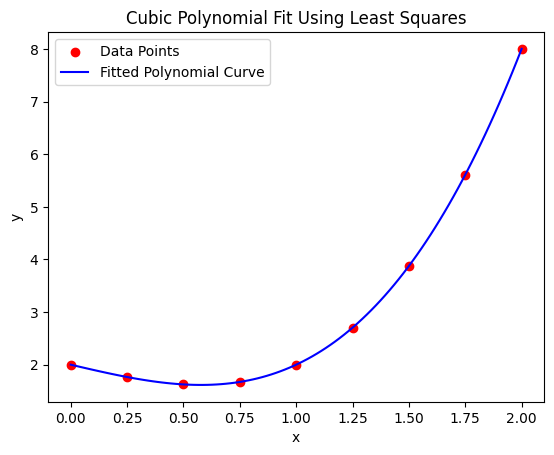

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 数据点 (x_i, y_i) 和权重 w_i
x_data = np.array([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
y_data = np.array([2.000, 1.766, 1.625, 1.672, 2.000, 2.703, 3.875, 5.609, 8.000])
weights = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1])  # 权重 w_i

# 构建设计矩阵 A
A = np.vstack([np.ones_like(x_data), x_data, x_data**2, x_data**3]).T

# 构建权重矩阵 W
W = np.diag(weights)

# 使用最小二乘法计算多项式系数 a
# a = (A^T W A)^(-1) * A^T * W * y
At_W = A.T @ W
a = np.linalg.inv(At_W @ A) @ (At_W @ y_data)

# 打印拟合的多项式系数
print("拟合的多项式系数为:", a)

# 可视化拟合曲线及数据点
x_fit = np.linspace(0, 2, 100)
y_fit = a[0] + a[1] * x_fit + a[2] * x_fit**2 + a[3] * x_fit**3

plt.scatter(x_data, y_data, color='red', label='Data Points')
plt.plot(x_fit, y_fit, label='Fitted Polynomial Curve', color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Cubic Polynomial Fit Using Least Squares')
plt.show()


### 代码说明
- **设计矩阵 A**：包含数据点的多项式项。
- **权重矩阵 W**：对角线上的元素为各数据点的权重。
- **最小二乘法计算**：根据公式求出多项式的系数。
- **可视化**：使用散点图展示数据点，并绘制拟合曲线以展示拟合效果。

### 结果
运行该代码后，可以看到拟合的多项式曲线，以及拟合曲线与数据点的对比，以验证多项式的拟合效果。

## 第 5A 题

### 双线性插值原理
假设在 3x3 网格数据中，给定一个二维数据矩阵 $ Z $，其中元素 $ Z[i][j] $ 表示坐标 $ (i, j) $ 上的值。若目标点坐标 $ (x, y) $ 是非整数，可以通过双线性插值估计其值。双线性插值的基本步骤如下：

1. **选择最近的四个邻点**：
   - 确定目标点 $ (x, y) $ 的整数部分 $ (i, j) $ 和小数部分。
   - 最近的四个点为 $ (i, j), (i+1, j), (i, j+1), (i+1, j+1) $。

2. **插值计算**：
   - 首先在 $ x $ 方向插值，然后在 $ y $ 方向插值：
   $$
   f(x, y) = (1 - dx)(1 - dy) Z[i][j] + dx(1 - dy) Z[i+1][j] + (1 - dx)dy Z[i][j+1] + dx \cdot dy \cdot Z[i+1][j+1]
   $$
   其中 $ dx = x - i $ 和 $ dy = y - j $ 分别为 $ x $ 和 $ y $ 的小数部分。

### 实现步骤
1. **函数定义**：创建一个 `bilinear_interpolation` 函数，该函数接受二维矩阵 $ Z $ 及坐标 $ (x, y) $，返回估计值。
2. **测试用例**：使用此函数计算一些点的插值结果。
3. **解释结果**：对比插值结果，解释双线性插值如何利用邻近点的信息来估计目标点的值。

### Python 代码实现
以下是双线性插值的代码实现和测试用例：

In [4]:
import numpy as np

def bilinear_interpolation(Z, x, y):
    # 获取邻近四个点的整数坐标
    i, j = int(x), int(y)
    dx, dy = x - i, y - j
    
    # 检查边界
    if i >= Z.shape[0] - 1 or j >= Z.shape[1] - 1:
        raise ValueError("Interpolation point is outside the grid.")

    # 四个邻近点的值
    Q11 = Z[i, j]
    Q21 = Z[i + 1, j]
    Q12 = Z[i, j + 1]
    Q22 = Z[i + 1, j + 1]
    
    # 计算插值
    f_xy = (1 - dx) * (1 - dy) * Q11 + dx * (1 - dy) * Q21 + (1 - dx) * dy * Q12 + dx * dy * Q22
    return f_xy

# 示例矩阵 Z (3x3)
Z = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# 测试插值点
points_to_interpolate = [(0.5, 0.5), (1.2, 1.7), (0.8, 1.3)]
results = {point: bilinear_interpolation(Z, *point) for point in points_to_interpolate}

# 显示结果
results

{(0.5, 0.5): np.float64(3.0),
 (1.2, 1.7): np.float64(6.299999999999999),
 (0.8, 1.3): np.float64(4.7)}

### 测试结果和解释
例如，对插值点 $ (0.5, 0.5) $、$ (1.2, 1.7) $、$ (0.8, 1.3) $ 进行计算，并返回相应的估计值。双线性插值方法利用四个邻近点的加权平均来平滑地估算目标点的值，从而提供了在二维平面上较平滑的过渡效果。

如有进一步问题，欢迎继续探讨！